# Car Price Prediction Using Machine Learning

This project focuses on analyzing car data and predicting car prices using machine learning techniques.

## Objectives
- Explore the car price dataset
- Perform data preprocessing
- Analyze relationships between features and car prices
- Train a Random Forest regression model
- Evaluate the model performance

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load Dataset

In [28]:
df = pd.read_csv('/content/drive/MyDrive/AI/CarPrice_Assignment (1).csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [30]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [31]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


## 2. Exploratory Data Analysis (EDA)

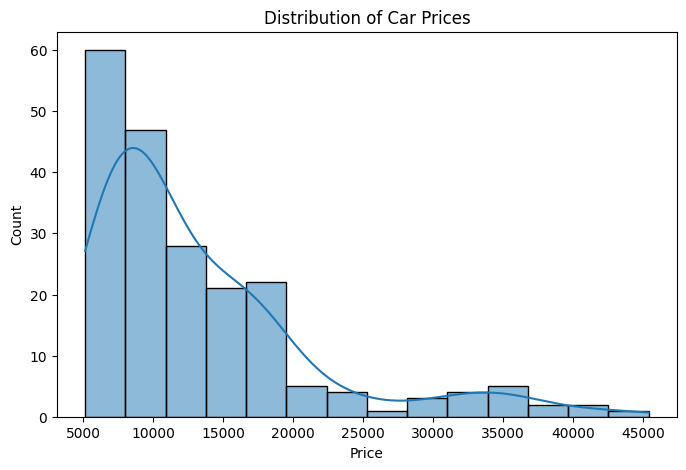

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

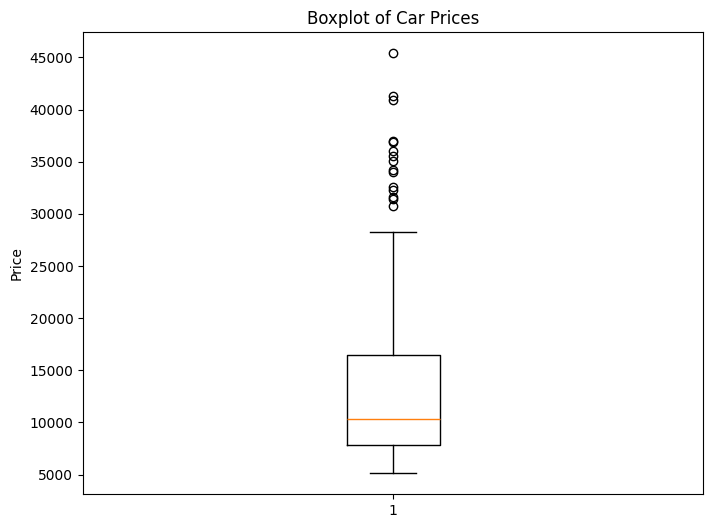

In [33]:
plt.figure(figsize=(8, 6))

plt.boxplot(df["price"])

plt.title("Boxplot of Car Prices")
plt.ylabel("Price")

plt.show()

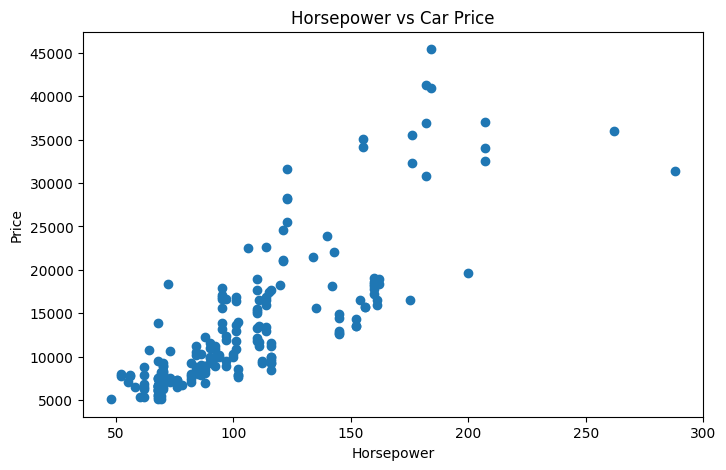

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(df["horsepower"], df["price"])

plt.title("Horsepower vs Car Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")

plt.show()

### Price Distribution Analysis

In [35]:
print("Skewness:", skew(df["price"]))
print("Kurtosis:", kurtosis(df["price"]))

Skewness: 1.7646442265113236
Kurtosis: 2.94859776828671


### EDA Summary

The car price distribution is positively skewed, with a skewness value of approximately 1.76. This indicates that most cars are concentrated in the lower-to-middle price range, while a smaller number of cars have considerably higher prices.

The relationship between vehicle characteristics such as curb weight and horsepower and car price also suggests that vehicle specifications can provide useful information for price prediction.

## 3. Data Preprocessing

In this step, the target variable (`price`) is separated from the input features. The `car_ID` column is removed because it is only an identifier and does not represent a meaningful car characteristic.

Categorical variables are converted into numerical features using one-hot encoding. The dataset is then split into training and testing sets.

In [36]:
X = df.drop(["price", "car_ID"], axis=1)
y = df["price"]

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training - Random Forest Regression

The Random Forest Regressor is trained using the preprocessed training data.

The model is configured with 300 trees, a maximum tree depth of 10, and a minimum of 4 samples per leaf. These parameters provide a balance between model complexity and generalization.

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42
)

In [41]:
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=4, n_estimators=300,
                      random_state=42)

In [42]:
y_pred = rf_model.predict(X_test_scaled)

In [43]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.942547655797119
Mean Squared Error: 4535519.060337524


## 5. Model Evaluation

In this section, the performance of the Random Forest model is evaluated using R² and Mean Squared Error (MSE).

Additional visualizations and train-test comparisons are used to better understand the model's prediction quality and generalization performance.

### Actual vs Predicted Prices

The following plot compares the actual car prices with the prices predicted by the Random Forest model. Points closer to the diagonal line indicate more accurate predictions.

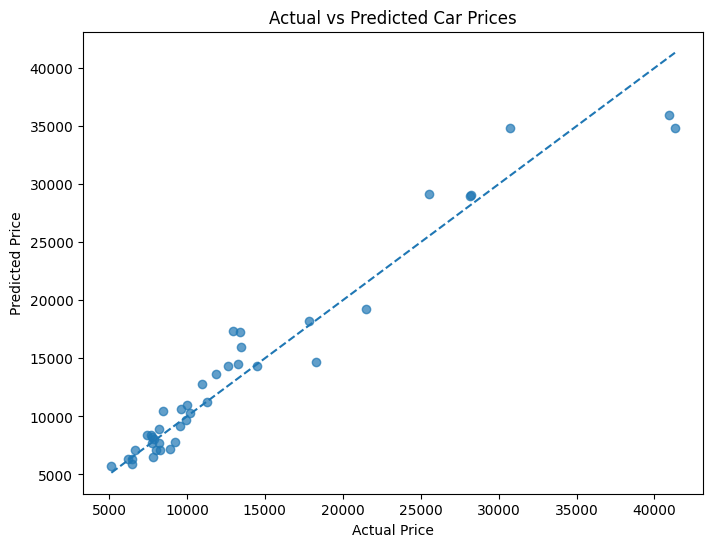

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Root Mean Squared Error (RMSE)

RMSE measures the average magnitude of prediction errors. Lower RMSE values indicate better predictive performance.

In [45]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2129.6758110889846


## 6. Feature Importance

### Top 10 Important Features

The following table shows the ten features that contribute most to the Random Forest model's predictions.

In [46]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,enginesize,0.604574
5,curbweight,0.264956
13,highwaympg,0.044300
10,horsepower,0.026150
3,carwidth,0.012687
2,carlength,0.007958
1,wheelbase,0.007527
12,citympg,0.005238
11,peakrpm,0.004797
8,stroke,0.003717


In [47]:
y_train_pred = rf_model.predict(X_train_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Train R²:", train_r2)
print("Test R²:", test_r2)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R²: 0.9594017695695621
Test R²: 0.942547655797119
Train RMSE: 1556.0175656367214
Test RMSE: 2129.6758110889846


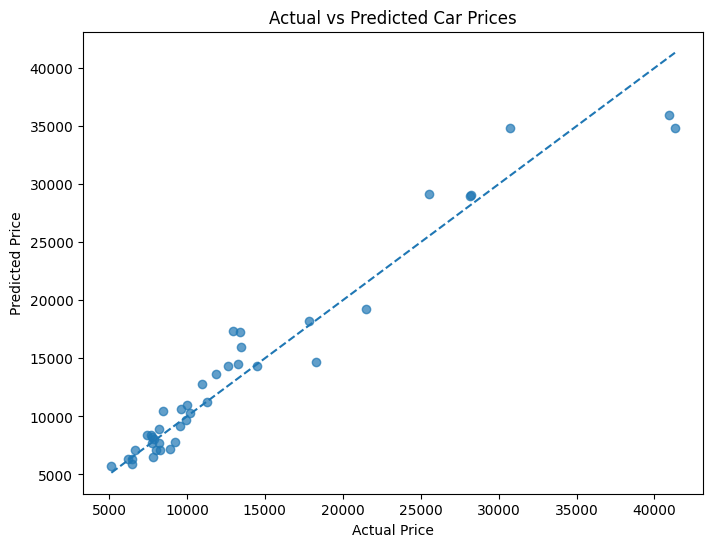

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Residual Analysis

Residuals represent the difference between the actual and predicted prices. A well-behaved residual plot should show errors distributed around zero without a strong systematic pattern.

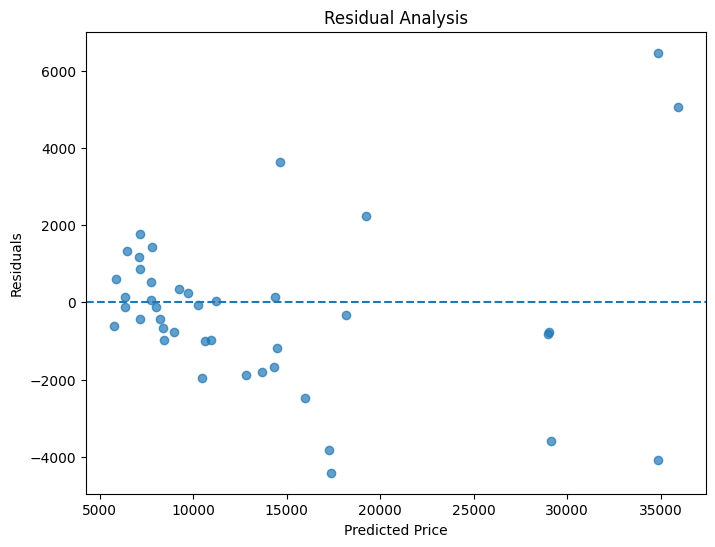

In [49]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()

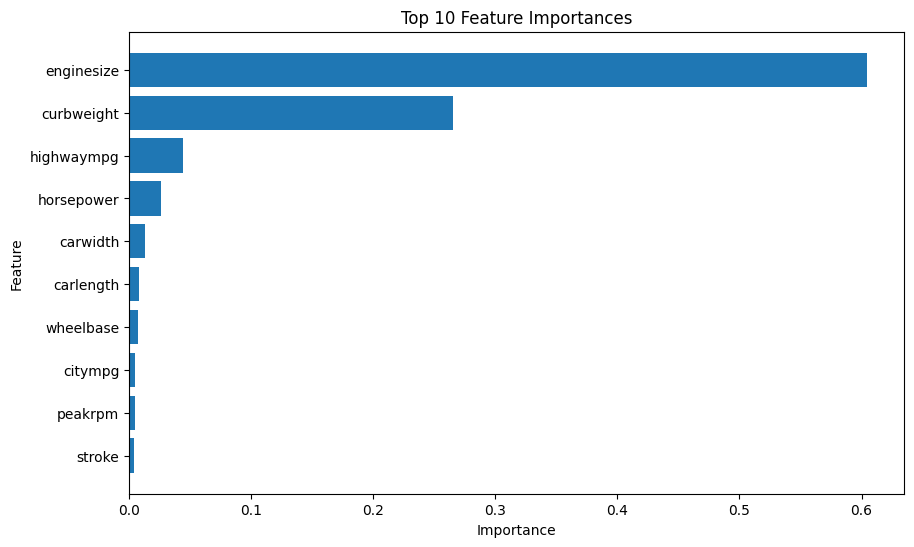

In [50]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

## 7. Conclusion

The Random Forest regression model achieved strong predictive performance on the car price dataset.

The model achieved a test R² score of approximately 0.94, indicating that it explains a large portion of the variation in car prices.

The comparison between training and testing performance suggests that the model generalizes well without severe overfitting.

Feature importance analysis shows that engine size (`enginesize`) and curb weight (`curbweight`) are among the most influential features used by the model for price prediction.